## MASTER DATA SCIENCE: NUCLIO
## PROFESOR: ALBERTO VACAS
## PROJECT TRENMAX

### IMPORTAMOS LIBRERÍAS Y LEEMOS EL FICHERO

In [7]:
# IMPORTAMOS LIBRERÍAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

In [8]:
# Cargar dataset
DATA_PATH = 'renfe.csv'

df_raw = pd.read_csv(DATA_PATH, sep=',', encoding='latin-1')

# Copia de trabajo para preservar el dataset original
df_renfe = df_raw.copy()

df_renfe.head()

,FECHA_CONSULTA,FECHA_INICIO,FECHA_FIN,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO
0,2019-05-25 01:43:03,2019-06-28 20:36:00,2019-06-28 23:14:00,SEVILLA,MADRID,ALVIA,Flexible,Turista,67.20
1,2019-06-22 13:05:11,2019-07-14 10:00:00,2019-07-14 13:10:00,BARCELONA,MADRID,AVE,Flexible,Turista,107.70
2,2019-04-17 06:24:03,2019-05-23 13:40:00,2019-05-23 16:10:00,SEVILLA,MADRID,AVE,Promo,Turista,47.30
3,2019-05-10 21:21:59,2019-05-29 14:50:00,2019-05-29 22:30:00,VALENCIA,MADRID,REGIONAL,Adulto ida,Turista,28.35
4,2019-05-09 19:43:37,2019-06-26 13:25:00,2019-06-26 16:24:00,MADRID,BARCELONA,AVE-TGV,Promo,Turista,66.75


### PARTE 1

#### PREGUNTA 1

¿Qué variables tienen nulos?

In [9]:
df_renfe.isnull().sum()

FECHA_CONSULTA        0
FECHA_INICIO          0
FECHA_FIN             0
CIUDAD_ORIGEN         0
CIUDAD_DESTINO        0
TIPO_TREN         38357
TIPO_TARIFA       39559
CLASE             39568
PRECIO            28530
dtype: int64

In [10]:
df_renfe.isnull().any()

FECHA_CONSULTA    False
FECHA_INICIO      False
FECHA_FIN         False
CIUDAD_ORIGEN     False
CIUDAD_DESTINO    False
TIPO_TREN          True
TIPO_TARIFA        True
CLASE              True
PRECIO             True
dtype: bool

#### PREGUNTA 2

Convertimos las fechas a formato datetime.

In [11]:
df_renfe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383568 entries, 0 to 383567
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   FECHA_CONSULTA  383568 non-null  object 
 1   FECHA_INICIO    383568 non-null  object 
 2   FECHA_FIN       383568 non-null  object 
 3   CIUDAD_ORIGEN   383568 non-null  object 
 4   CIUDAD_DESTINO  383568 non-null  object 
 5   TIPO_TREN       345211 non-null  object 
 6   TIPO_TARIFA     344009 non-null  object 
 7   CLASE           344000 non-null  object 
 8   PRECIO          355038 non-null  float64
dtypes: float64(1), object(8)
memory usage: 26.3+ MB


In [12]:
for i in ["FECHA_CONSULTA","FECHA_INICIO","FECHA_FIN"]:
    df_renfe[i] = pd.to_datetime(df_renfe[i])

In [13]:
df_renfe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383568 entries, 0 to 383567
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   FECHA_CONSULTA  383568 non-null  datetime64[ns]
 1   FECHA_INICIO    383568 non-null  datetime64[ns]
 2   FECHA_FIN       383568 non-null  datetime64[ns]
 3   CIUDAD_ORIGEN   383568 non-null  object        
 4   CIUDAD_DESTINO  383568 non-null  object        
 5   TIPO_TREN       345211 non-null  object        
 6   TIPO_TARIFA     344009 non-null  object        
 7   CLASE           344000 non-null  object        
 8   PRECIO          355038 non-null  float64       
dtypes: datetime64[ns](3), float64(1), object(5)
memory usage: 26.3+ MB


#### PREGUNTA 3

Eliminamos duplicados.

In [14]:
df_renfe[df_renfe.duplicated(keep='first')]

,FECHA_CONSULTA,FECHA_INICIO,FECHA_FIN,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO
67494,2019-04-29 23:15:13,2019-05-14 06:20:00,2019-05-14 14:25:00,MADRID,BARCELONA,LD-AVE,Promo,Turista,NaN
82429,2019-04-30 09:09:51,2019-05-19 17:30:00,2019-05-19 19:43:00,VALENCIA,MADRID,INTERCITY,Flexible,Turista,55.40
88401,2019-05-15 23:37:01,2019-06-21 21:05:00,2019-06-21 23:32:00,VALENCIA,MADRID,INTERCITY,NaN,NaN,NaN
107458,2019-06-12 11:51:44,2019-06-16 17:30:00,2019-06-16 19:43:00,VALENCIA,MADRID,INTERCITY,Flexible,TuristaSólo plaza H,55.40
143395,2019-08-17 03:22:19,2019-09-01 21:03:00,2019-09-01 23:28:00,VALENCIA,MADRID,INTERCITY,Flexible,Turista,NaN
159167,2019-05-16 13:12:07,2019-06-29 21:05:00,2019-06-29 23:32:00,VALENCIA,MADRID,INTERCITY,NaN,NaN,NaN
170659,2019-05-15 21:26:30,2019-06-23 21:05:00,2019-06-23 23:32:00,VALENCIA,MADRID,INTERCITY,NaN,NaN,NaN
191339,2019-08-18 17:34:03,2019-08-23 21:03:00,2019-08-23 23:28:00,VALENCIA,MADRID,INTERCITY,Flexible,Turista,55.40
235466,2019-06-18 23:16:29,2019-07-23 07:00:00,2019-07-23 14:25:00,MADRID,BARCELONA,LD-AVE,Promo,Turista Plus,NaN
241656,2019-05-14 03:01:42,2019-07-07 21:05:00,2019-07-07 23:32:00,VALENCIA,MADRID,INTERCITY,Promo,Turista,NaN


In [15]:
df_renfe[df_renfe.duplicated()].shape

(24, 9)

In [16]:
df_renfe_sin_duplicados = df_renfe.drop_duplicates().copy()

In [17]:
df_renfe_sin_duplicados.head()

,FECHA_CONSULTA,FECHA_INICIO,FECHA_FIN,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO
0,2019-05-25 01:43:03,2019-06-28 20:36:00,2019-06-28 23:14:00,SEVILLA,MADRID,ALVIA,Flexible,Turista,67.20
1,2019-06-22 13:05:11,2019-07-14 10:00:00,2019-07-14 13:10:00,BARCELONA,MADRID,AVE,Flexible,Turista,107.70
2,2019-04-17 06:24:03,2019-05-23 13:40:00,2019-05-23 16:10:00,SEVILLA,MADRID,AVE,Promo,Turista,47.30
3,2019-05-10 21:21:59,2019-05-29 14:50:00,2019-05-29 22:30:00,VALENCIA,MADRID,REGIONAL,Adulto ida,Turista,28.35
4,2019-05-09 19:43:37,2019-06-26 13:25:00,2019-06-26 16:24:00,MADRID,BARCELONA,AVE-TGV,Promo,Turista,66.75


In [18]:
df_renfe.shape

(383568, 9)

In [19]:
df_renfe_sin_duplicados.shape

(383544, 9)

In [20]:
df_renfe_sin_duplicados.tail()

,FECHA_CONSULTA,FECHA_INICIO,FECHA_FIN,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO
383563,2019-05-06 05:11:53,2019-05-10 19:40:00,2019-05-10 21:29:00,MADRID,VALENCIA,AVE,Flexible,NaN,73.10
383564,2019-06-19 21:48:56,2019-08-05 20:00:00,2019-08-05 23:10:00,BARCELONA,MADRID,AVE,Promo,Preferente,54.45
383565,2019-04-24 23:21:44,2019-04-29 16:15:00,2019-04-29 17:55:00,VALENCIA,MADRID,AVE,Promo,Turista,27.80
383566,2019-05-27 21:05:19,2019-07-07 15:00:00,2019-07-07 17:21:00,MADRID,SEVILLA,AVE,Promo,NaN,47.30
383567,2019-05-27 15:04:14,2019-06-16 18:35:00,2019-06-16 20:21:00,VALENCIA,MADRID,AVE,Flexible,Turista,73.10


In [21]:
df_renfe_sin_duplicados.reset_index(drop=True, inplace=True)

In [22]:
df_renfe_sin_duplicados.tail()

,FECHA_CONSULTA,FECHA_INICIO,FECHA_FIN,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO
383539,2019-05-06 05:11:53,2019-05-10 19:40:00,2019-05-10 21:29:00,MADRID,VALENCIA,AVE,Flexible,NaN,73.10
383540,2019-06-19 21:48:56,2019-08-05 20:00:00,2019-08-05 23:10:00,BARCELONA,MADRID,AVE,Promo,Preferente,54.45
383541,2019-04-24 23:21:44,2019-04-29 16:15:00,2019-04-29 17:55:00,VALENCIA,MADRID,AVE,Promo,Turista,27.80
383542,2019-05-27 21:05:19,2019-07-07 15:00:00,2019-07-07 17:21:00,MADRID,SEVILLA,AVE,Promo,NaN,47.30
383543,2019-05-27 15:04:14,2019-06-16 18:35:00,2019-06-16 20:21:00,VALENCIA,MADRID,AVE,Flexible,Turista,73.10


In [23]:
df_renfe_sin_duplicados[df_renfe_sin_duplicados.duplicated()].shape

(0, 9)

In [24]:
df_renfe_sin_duplicados[df_renfe_sin_duplicados.duplicated()]

,FECHA_CONSULTA,FECHA_INICIO,FECHA_FIN,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO


#### PREGUNTA 4

Creamos las variables TIEMPO_VIAJE (variable que indica en minutos la duración del viaje) y DIF_INI_BUS (variable que indica en minutos la diferencia entre la fecha de inicio de viaje y la fecha de búsqueda).

In [25]:
df_renfe_sin_duplicados["TIEMPO_VIAJE"] = (df_renfe_sin_duplicados["FECHA_FIN"]-df_renfe_sin_duplicados["FECHA_INICIO"])/np.timedelta64(1,'m')

In [26]:
df_renfe_sin_duplicados["DIF_INI_BUS"] = (df_renfe_sin_duplicados["FECHA_INICIO"]-df_renfe_sin_duplicados["FECHA_CONSULTA"])/np.timedelta64(1,'m')

In [27]:
df_renfe_sin_duplicados.head()

,FECHA_CONSULTA,FECHA_INICIO,FECHA_FIN,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO,TIEMPO_VIAJE,DIF_INI_BUS
0,2019-05-25 01:43:03,2019-06-28 20:36:00,2019-06-28 23:14:00,SEVILLA,MADRID,ALVIA,Flexible,Turista,67.20,158.0,50092.950000
1,2019-06-22 13:05:11,2019-07-14 10:00:00,2019-07-14 13:10:00,BARCELONA,MADRID,AVE,Flexible,Turista,107.70,190.0,31494.816667
2,2019-04-17 06:24:03,2019-05-23 13:40:00,2019-05-23 16:10:00,SEVILLA,MADRID,AVE,Promo,Turista,47.30,150.0,52275.950000
3,2019-05-10 21:21:59,2019-05-29 14:50:00,2019-05-29 22:30:00,VALENCIA,MADRID,REGIONAL,Adulto ida,Turista,28.35,460.0,26968.016667
4,2019-05-09 19:43:37,2019-06-26 13:25:00,2019-06-26 16:24:00,MADRID,BARCELONA,AVE-TGV,Promo,Turista,66.75,179.0,68741.383333


#### PREGUNTA 5

Este código separa las fechas en hora, día (nombre), día (número) y mes.

In [28]:
for col in ['FECHA_CONSULTA', 'FECHA_INICIO', 'FECHA_FIN']:

    df_renfe_sin_duplicados[col + '_HORA'] = df_renfe_sin_duplicados[col].dt.hour
    df_renfe_sin_duplicados[col + '_NOMBREDIA'] = df_renfe_sin_duplicados[col].dt.day_name()
    df_renfe_sin_duplicados[col + '_DIA'] = df_renfe_sin_duplicados[col].dt.day
    df_renfe_sin_duplicados[col + '_MES'] = df_renfe_sin_duplicados[col].dt.month

    del(df_renfe_sin_duplicados[col])

df_renfe_sin_duplicados.head()

,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO,TIEMPO_VIAJE,DIF_INI_BUS,FECHA_CONSULTA_HORA,FECHA_CONSULTA_NOMBREDIA,FECHA_CONSULTA_DIA,FECHA_CONSULTA_MES,FECHA_INICIO_HORA,FECHA_INICIO_NOMBREDIA,FECHA_INICIO_DIA,FECHA_INICIO_MES,FECHA_FIN_HORA,FECHA_FIN_NOMBREDIA,FECHA_FIN_DIA,FECHA_FIN_MES
0,SEVILLA,MADRID,ALVIA,Flexible,Turista,67.20,158.0,50092.950000,1,Saturday,25,5,20,Friday,28,6,23,Friday,28,6
1,BARCELONA,MADRID,AVE,Flexible,Turista,107.70,190.0,31494.816667,13,Saturday,22,6,10,Sunday,14,7,13,Sunday,14,7
2,SEVILLA,MADRID,AVE,Promo,Turista,47.30,150.0,52275.950000,6,Wednesday,17,4,13,Thursday,23,5,16,Thursday,23,5
3,VALENCIA,MADRID,REGIONAL,Adulto ida,Turista,28.35,460.0,26968.016667,21,Friday,10,5,14,Wednesday,29,5,22,Wednesday,29,5
4,MADRID,BARCELONA,AVE-TGV,Promo,Turista,66.75,179.0,68741.383333,19,Thursday,9,5,13,Wednesday,26,6,16,Wednesday,26,6


#### PREGUNTA 6

Calculamos el porcentaje de nulos.

In [29]:
df_renfe_sin_duplicados["PRECIO"].isnull().sum()

np.int64(28516)

In [30]:
df_renfe_sin_duplicados.shape[0]

383544

In [31]:
(df_renfe_sin_duplicados["PRECIO"].isnull().sum()/df_renfe_sin_duplicados.shape[0])*100

np.float64(7.434870575475043)

In [32]:
df_renfe_sin_duplicados["PRECIO"].value_counts(dropna=False,normalize=True)*100

PRECIO
NaN       7.434871
85.10     4.857070
28.35     4.799710
76.30     4.579918
107.70    3.588115
            ...   
342.80    0.000261
30.91     0.000261
29.75     0.000261
57.05     0.000261
49.14     0.000261
Name: proportion, Length: 293, dtype: float64

#### PREGUNTA 7

Analizamos y limpiamos los nulos.

In [33]:
df_renfe_sin_duplicados.isnull().sum()

CIUDAD_ORIGEN                   0
CIUDAD_DESTINO                  0
TIPO_TREN                   38357
TIPO_TARIFA                 39554
CLASE                       39563
PRECIO                      28516
TIEMPO_VIAJE                    0
DIF_INI_BUS                     0
FECHA_CONSULTA_HORA             0
FECHA_CONSULTA_NOMBREDIA        0
FECHA_CONSULTA_DIA              0
FECHA_CONSULTA_MES              0
FECHA_INICIO_HORA               0
FECHA_INICIO_NOMBREDIA          0
FECHA_INICIO_DIA                0
FECHA_INICIO_MES                0
FECHA_FIN_HORA                  0
FECHA_FIN_NOMBREDIA             0
FECHA_FIN_DIA                   0
FECHA_FIN_MES                   0
dtype: int64

In [34]:
df_renfe_sin_duplicados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383544 entries, 0 to 383543
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   CIUDAD_ORIGEN             383544 non-null  object 
 1   CIUDAD_DESTINO            383544 non-null  object 
 2   TIPO_TREN                 345187 non-null  object 
 3   TIPO_TARIFA               343990 non-null  object 
 4   CLASE                     343981 non-null  object 
 5   PRECIO                    355028 non-null  float64
 6   TIEMPO_VIAJE              383544 non-null  float64
 7   DIF_INI_BUS               383544 non-null  float64
 8   FECHA_CONSULTA_HORA       383544 non-null  int32  
 9   FECHA_CONSULTA_NOMBREDIA  383544 non-null  object 
 10  FECHA_CONSULTA_DIA        383544 non-null  int32  
 11  FECHA_CONSULTA_MES        383544 non-null  int32  
 12  FECHA_INICIO_HORA         383544 non-null  int32  
 13  FECHA_INICIO_NOMBREDIA    383544 non-null  o

array([[<Axes: title={'center': 'PRECIO'}>]], dtype=object)

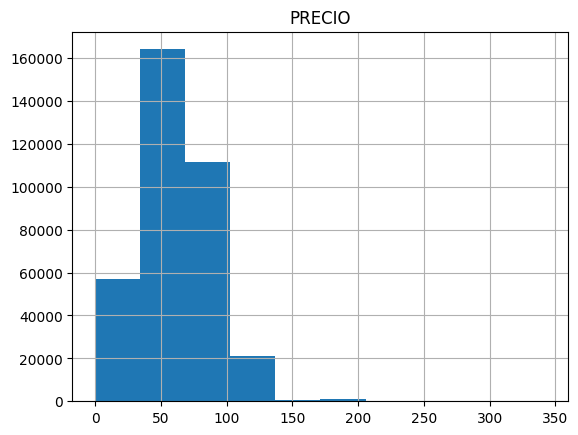

In [35]:
df_renfe_sin_duplicados.hist("PRECIO")

In [36]:
df_renfe_sin_duplicados["TIPO_TREN"].value_counts()

TIPO_TREN
AVE          236293
ALVIA         27231
INTERCITY     17827
REGIONAL      16817
AV City        9754
MD-LD          7475
LD             5905
AVE-TGV        4593
R. EXPRES      4165
TRENHOTEL      3956
AVE-LD         3505
AVE-MD         2955
LD-MD          2793
MD-AVE          871
MD              548
LD-AVE          499
Name: count, dtype: int64

In [37]:
df_renfe_sin_duplicados["TIPO_TARIFA"].value_counts()

TIPO_TARIFA
Promo                      239839
Flexible                    74133
Adulto ida                  21624
Promo +                      8222
COD.PROMOCIONAL               148
Individual-Flexible            11
Mesa                            8
Doble Familiar-Flexible         3
4x100                           1
Grupos Ida                      1
Name: count, dtype: int64

In [38]:
df_renfe_sin_duplicados["CLASE"].value_counts()

CLASE
Turista                     261731
Preferente                   33963
Turista Plus                 24347
Turista con enlace           20866
TuristaSólo plaza H           2477
PreferenteSólo plaza H         317
Cama Turista                   263
Cama G. Clase                   15
Turista PlusSólo plaza H         2
Name: count, dtype: int64

Analizamos variable target

In [39]:
df_renfe_sin_duplicados_nulos = df_renfe_sin_duplicados.copy()

In [40]:
df_renfe_sin_duplicados_nulos.dropna(subset=["PRECIO"], inplace=True) ##Eliminamos los nulos del target

Analizamos resto variable con nulos

In [41]:
df_renfe_sin_duplicados_nulos[(df_renfe_sin_duplicados_nulos['TIPO_TREN'].isnull()) &
                              (df_renfe_sin_duplicados_nulos['TIPO_TARIFA'].isnull()) &
                              (df_renfe_sin_duplicados_nulos['CLASE'].isnull())]

,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO,TIEMPO_VIAJE,DIF_INI_BUS,FECHA_CONSULTA_HORA,FECHA_CONSULTA_NOMBREDIA,FECHA_CONSULTA_DIA,FECHA_CONSULTA_MES,FECHA_INICIO_HORA,FECHA_INICIO_NOMBREDIA,FECHA_INICIO_DIA,FECHA_INICIO_MES,FECHA_FIN_HORA,FECHA_FIN_NOMBREDIA,FECHA_FIN_DIA,FECHA_FIN_MES
3278,MADRID,BARCELONA,NaN,NaN,NaN,68.95,190.0,65510.400000,7,Friday,7,6,19,Monday,22,7,22,Monday,22,7
4228,SEVILLA,MADRID,NaN,NaN,NaN,53.40,160.0,45733.500000,13,Saturday,17,8,7,Wednesday,18,9,9,Wednesday,18,9
4663,BARCELONA,MADRID,NaN,NaN,NaN,85.10,190.0,52611.333333,21,Saturday,25,5,10,Monday,1,7,13,Monday,1,7
5291,MADRID,SEVILLA,NaN,NaN,NaN,53.40,150.0,67137.716667,1,Tuesday,18,6,16,Saturday,3,8,18,Saturday,3,8
5294,MADRID,VALENCIA,NaN,NaN,NaN,17.15,250.0,47174.166667,23,Thursday,25,4,17,Tuesday,28,5,21,Tuesday,28,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377520,MADRID,SEVILLA,NaN,NaN,NaN,53.40,160.0,16526.216667,9,Sunday,18,8,20,Thursday,29,8,23,Thursday,29,8
377994,VALENCIA,MADRID,NaN,NaN,NaN,21.95,100.0,70193.000000,1,Saturday,1,6,19,Friday,19,7,20,Friday,19,7
381242,MADRID,SEVILLA,NaN,NaN,NaN,60.30,152.0,26410.883333,5,Sunday,21,4,14,Thursday,9,5,16,Thursday,9,5
382855,BARCELONA,MADRID,NaN,NaN,NaN,43.25,544.0,939.383333,17,Friday,21,6,9,Saturday,22,6,18,Saturday,22,6


In [42]:
df_renfe_sin_duplicados_nulos.shape

(355028, 20)

In [43]:
df_renfe_sin_duplicados_nulos.dropna(subset=["TIPO_TREN","TIPO_TARIFA","CLASE"], how='all', inplace=True) ##Eliminamos los que tengan las 3 columnas a nulo

In [44]:
df_renfe_sin_duplicados_nulos.shape

(354673, 20)

Variable Clase

In [45]:
COLUMNS_1 = ['CIUDAD_ORIGEN','CIUDAD_DESTINO',"TIPO_TREN","TIPO_TARIFA"]
df_nulls_1 = df_renfe_sin_duplicados_nulos.groupby(COLUMNS_1)['CLASE'].agg(lambda x: pd.Series.mode(x).iloc[0] if not pd.Series.mode(x).empty else np.nan).to_frame().reset_index()
df_nulls_1 = df_nulls_1.dropna(subset=['CLASE'])
df_nulls_1.rename(columns={"CLASE":"CLASE_1"},inplace=True)

COLUMNS_2 = ['CIUDAD_ORIGEN','CIUDAD_DESTINO',"TIPO_TREN"]
df_nulls_2 = df_renfe_sin_duplicados_nulos.groupby(COLUMNS_2)['CLASE'].agg(lambda x: pd.Series.mode(x).iloc[0] if not pd.Series.mode(x).empty else np.nan).to_frame().reset_index()
df_nulls_2 = df_nulls_2.dropna(subset=['CLASE'])
df_nulls_2.rename(columns={"CLASE":"CLASE_2"},inplace=True)

COLUMNS_3 = ['CIUDAD_ORIGEN','CIUDAD_DESTINO',"TIPO_TARIFA"]
df_nulls_3 = df_renfe_sin_duplicados_nulos.groupby(COLUMNS_3)['CLASE'].agg(lambda x: pd.Series.mode(x).iloc[0] if not pd.Series.mode(x).empty else np.nan).to_frame().reset_index()
df_nulls_3 = df_nulls_3.dropna(subset=['CLASE'])
df_nulls_3.rename(columns={"CLASE":"CLASE_3"},inplace=True)

In [46]:
df_renfe_sin_duplicados_nulos = df_renfe_sin_duplicados_nulos.merge(df_nulls_1,how='left',left_on=COLUMNS_1,right_on=COLUMNS_1)
df_renfe_sin_duplicados_nulos = df_renfe_sin_duplicados_nulos.merge(df_nulls_2,how='left',left_on=COLUMNS_2,right_on=COLUMNS_2)
df_renfe_sin_duplicados_nulos = df_renfe_sin_duplicados_nulos.merge(df_nulls_3,how='left',left_on=COLUMNS_3,right_on=COLUMNS_3)

df_renfe_sin_duplicados_nulos['CLASE'] = df_renfe_sin_duplicados_nulos[['CLASE','CLASE_1','CLASE_2','CLASE_3']].bfill(axis=1).bfill(axis=1).iloc[:, 0]

df_renfe_sin_duplicados_nulos.drop(columns=['CLASE_1','CLASE_2','CLASE_3'],inplace=True)

Variable Tipo tarifa

In [47]:
COLUMNS_1 = ['CIUDAD_ORIGEN','CIUDAD_DESTINO',"TIPO_TREN","CLASE"]
df_nulls_1 = df_renfe_sin_duplicados_nulos.groupby(COLUMNS_1)['TIPO_TARIFA'].agg(lambda x: pd.Series.mode(x).iloc[0] if not pd.Series.mode(x).empty else np.nan).to_frame().reset_index()
df_nulls_1 = df_nulls_1.dropna(subset=['TIPO_TARIFA'])
df_nulls_1.rename(columns={"TIPO_TARIFA":"TIPO_TARIFA_1"},inplace=True)

COLUMNS_2 = ['CIUDAD_ORIGEN','CIUDAD_DESTINO',"TIPO_TREN"]
df_nulls_2 = df_renfe_sin_duplicados_nulos.groupby(COLUMNS_2)['TIPO_TARIFA'].agg(lambda x: pd.Series.mode(x).iloc[0] if not pd.Series.mode(x).empty else np.nan).to_frame().reset_index()
df_nulls_2 = df_nulls_2.dropna(subset=['TIPO_TARIFA'])
df_nulls_2.rename(columns={"TIPO_TARIFA":"TIPO_TARIFA_2"},inplace=True)

COLUMNS_3 = ['CIUDAD_ORIGEN','CIUDAD_DESTINO',"CLASE"]
df_nulls_3 = df_renfe_sin_duplicados_nulos.groupby(COLUMNS_3)['TIPO_TARIFA'].agg(lambda x: pd.Series.mode(x).iloc[0] if not pd.Series.mode(x).empty else np.nan).to_frame().reset_index()
df_nulls_3 = df_nulls_3.dropna(subset=['TIPO_TARIFA'])
df_nulls_3.rename(columns={"TIPO_TARIFA":"TIPO_TARIFA_3"},inplace=True)

In [48]:
df_renfe_sin_duplicados_nulos = df_renfe_sin_duplicados_nulos.merge(df_nulls_1,how='left',left_on=COLUMNS_1,right_on=COLUMNS_1)
df_renfe_sin_duplicados_nulos = df_renfe_sin_duplicados_nulos.merge(df_nulls_2,how='left',left_on=COLUMNS_2,right_on=COLUMNS_2)
df_renfe_sin_duplicados_nulos = df_renfe_sin_duplicados_nulos.merge(df_nulls_3,how='left',left_on=COLUMNS_3,right_on=COLUMNS_3)

df_renfe_sin_duplicados_nulos['TIPO_TARIFA'] = df_renfe_sin_duplicados_nulos[['TIPO_TARIFA','TIPO_TARIFA_1','TIPO_TARIFA_2','TIPO_TARIFA_3']].bfill(axis=1).bfill(axis=1).iloc[:, 0]

df_renfe_sin_duplicados_nulos.drop(columns=['TIPO_TARIFA_1','TIPO_TARIFA_2','TIPO_TARIFA_3'],inplace=True)

Variable Tipo tren

In [49]:
COLUMNS_1 = ['CIUDAD_ORIGEN','CIUDAD_DESTINO',"TIPO_TARIFA","CLASE"]
df_nulls_1 = df_renfe_sin_duplicados_nulos.groupby(COLUMNS_1)['TIPO_TREN'].agg(lambda x: pd.Series.mode(x).iloc[0] if not pd.Series.mode(x).empty else np.nan).reset_index()
df_nulls_1 = df_nulls_1.dropna(subset=['TIPO_TREN'])
df_nulls_1.rename(columns={"TIPO_TREN":"TIPO_TREN_1"},inplace=True)

COLUMNS_2 = ['CIUDAD_ORIGEN','CIUDAD_DESTINO',"TIPO_TARIFA"]
df_nulls_2 = df_renfe_sin_duplicados_nulos.groupby(COLUMNS_2)['TIPO_TREN'].agg(lambda x: pd.Series.mode(x).iloc[0] if not pd.Series.mode(x).empty else np.nan).to_frame().reset_index()
df_nulls_2 = df_nulls_2.dropna(subset=['TIPO_TREN'])
df_nulls_2.rename(columns={"TIPO_TREN":"TIPO_TREN_2"},inplace=True)

COLUMNS_3 = ['CIUDAD_ORIGEN','CIUDAD_DESTINO',"CLASE"]
df_nulls_3 = df_renfe_sin_duplicados_nulos.groupby(COLUMNS_3)['TIPO_TREN'].agg(lambda x: pd.Series.mode(x).iloc[0] if not pd.Series.mode(x).empty else np.nan).to_frame().reset_index()
df_nulls_3 = df_nulls_3.dropna(subset=['TIPO_TREN'])
df_nulls_3.rename(columns={"TIPO_TREN":"TIPO_TREN_3"},inplace=True)

In [50]:
df_renfe_sin_duplicados_nulos = df_renfe_sin_duplicados_nulos.merge(df_nulls_1,how='left',left_on=COLUMNS_1,right_on=COLUMNS_1)
df_renfe_sin_duplicados_nulos = df_renfe_sin_duplicados_nulos.merge(df_nulls_2,how='left',left_on=COLUMNS_2,right_on=COLUMNS_2)
df_renfe_sin_duplicados_nulos = df_renfe_sin_duplicados_nulos.merge(df_nulls_3,how='left',left_on=COLUMNS_3,right_on=COLUMNS_3)

df_renfe_sin_duplicados_nulos['TIPO_TREN'] = df_renfe_sin_duplicados_nulos[['TIPO_TREN','TIPO_TREN_1','TIPO_TREN_2','TIPO_TREN_3']].bfill(axis=1).bfill(axis=1).iloc[:, 0]

df_renfe_sin_duplicados_nulos.drop(columns=['TIPO_TREN_1','TIPO_TREN_2','TIPO_TREN_3'],inplace=True)

In [51]:
df_renfe_sin_duplicados_nulos.isnull().sum()

CIUDAD_ORIGEN               0
CIUDAD_DESTINO              0
TIPO_TREN                   0
TIPO_TARIFA                 0
CLASE                       0
PRECIO                      0
TIEMPO_VIAJE                0
DIF_INI_BUS                 0
FECHA_CONSULTA_HORA         0
FECHA_CONSULTA_NOMBREDIA    0
FECHA_CONSULTA_DIA          0
FECHA_CONSULTA_MES          0
FECHA_INICIO_HORA           0
FECHA_INICIO_NOMBREDIA      0
FECHA_INICIO_DIA            0
FECHA_INICIO_MES            0
FECHA_FIN_HORA              0
FECHA_FIN_NOMBREDIA         0
FECHA_FIN_DIA               0
FECHA_FIN_MES               0
dtype: int64

In [52]:
df_renfe_sin_duplicados.shape

(383544, 20)

In [53]:
df_renfe_sin_duplicados_nulos.shape

(354673, 20)

#### PREGUNTA 8

Analizamos y limpiamos el resto de variables.

In [54]:
df_renfe_sin_duplicados_nulos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354673 entries, 0 to 354672
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   CIUDAD_ORIGEN             354673 non-null  object 
 1   CIUDAD_DESTINO            354673 non-null  object 
 2   TIPO_TREN                 354673 non-null  object 
 3   TIPO_TARIFA               354673 non-null  object 
 4   CLASE                     354673 non-null  object 
 5   PRECIO                    354673 non-null  float64
 6   TIEMPO_VIAJE              354673 non-null  float64
 7   DIF_INI_BUS               354673 non-null  float64
 8   FECHA_CONSULTA_HORA       354673 non-null  int32  
 9   FECHA_CONSULTA_NOMBREDIA  354673 non-null  object 
 10  FECHA_CONSULTA_DIA        354673 non-null  int32  
 11  FECHA_CONSULTA_MES        354673 non-null  int32  
 12  FECHA_INICIO_HORA         354673 non-null  int32  
 13  FECHA_INICIO_NOMBREDIA    354673 non-null  o

In [55]:
df_renfe_sin_duplicados_nulos_outliers = df_renfe_sin_duplicados_nulos.copy()

Analizamos variable target

<Axes: >

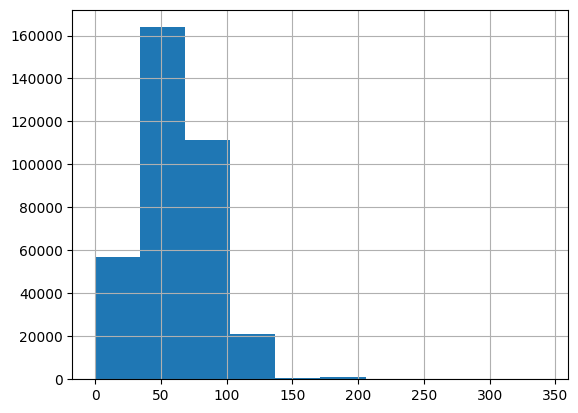

In [56]:
df_renfe_sin_duplicados_nulos_outliers["PRECIO"].hist()

In [57]:
df_renfe_sin_duplicados_nulos_outliers[df_renfe_sin_duplicados_nulos_outliers["PRECIO"]<=0]

,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO,TIEMPO_VIAJE,DIF_INI_BUS,FECHA_CONSULTA_HORA,FECHA_CONSULTA_NOMBREDIA,FECHA_CONSULTA_DIA,FECHA_CONSULTA_MES,FECHA_INICIO_HORA,FECHA_INICIO_NOMBREDIA,FECHA_INICIO_DIA,FECHA_INICIO_MES,FECHA_FIN_HORA,FECHA_FIN_NOMBREDIA,FECHA_FIN_DIA,FECHA_FIN_MES
112718,BARCELONA,MADRID,AVE,4x100,Turista,0.0,190.0,68338.650000,9,Monday,17,6,20,Saturday,3,8,23,Saturday,3,8
126539,BARCELONA,MADRID,AVE-TGV,Flexible,Preferente,0.0,175.0,5016.516667,1,Thursday,13,6,12,Sunday,16,6,15,Sunday,16,6


In [58]:
df_renfe_sin_duplicados_nulos_outliers.drop(df_renfe_sin_duplicados_nulos_outliers[df_renfe_sin_duplicados_nulos_outliers["PRECIO"]<=0].index, axis=0, inplace=True)

<Axes: xlabel='PRECIO'>

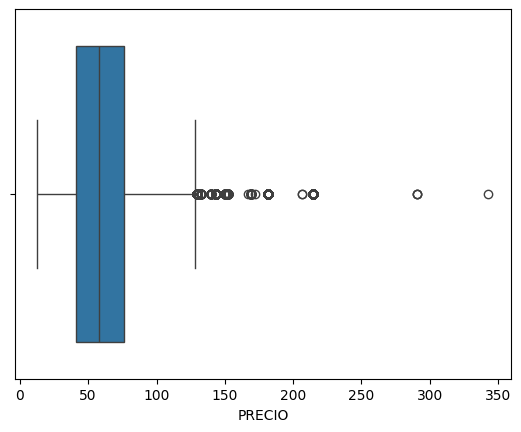

In [59]:
sns.boxplot(x = df_renfe_sin_duplicados_nulos_outliers["PRECIO"])

In [60]:
Q1=df_renfe_sin_duplicados_nulos_outliers['PRECIO'].quantile(0.1)
Q3=df_renfe_sin_duplicados_nulos_outliers['PRECIO'].quantile(0.9)

IQR = Q3 - Q1

indexes_low = df_renfe_sin_duplicados_nulos_outliers[df_renfe_sin_duplicados_nulos_outliers['PRECIO']<(Q1-1.5*IQR)].index
indexes_high = df_renfe_sin_duplicados_nulos_outliers[df_renfe_sin_duplicados_nulos_outliers['PRECIO']>(Q3+ 1.5*IQR)].index

In [61]:
max_precio = df_renfe_sin_duplicados_nulos_outliers[df_renfe_sin_duplicados_nulos_outliers['PRECIO']<(Q3+ 1.5*IQR)]['PRECIO'].max()
df_renfe_sin_duplicados_nulos_outliers.loc[indexes_high,'PRECIO']= max_precio

<Axes: xlabel='PRECIO'>

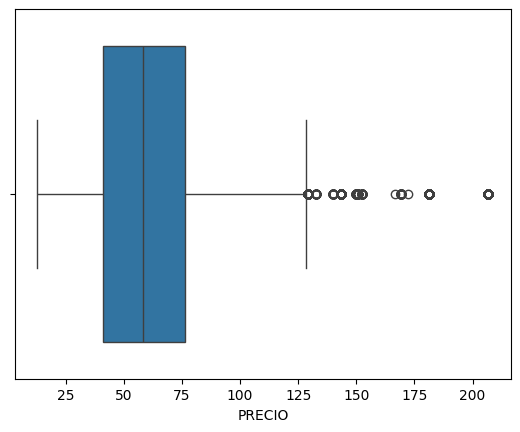

In [62]:
sns.boxplot(x = df_renfe_sin_duplicados_nulos_outliers["PRECIO"])

Analizamos resto variable con outilers

In [63]:
for i in df_renfe_sin_duplicados_nulos_outliers:
  print(i,df_renfe_sin_duplicados_nulos_outliers[i].dtype.kind)

CIUDAD_ORIGEN O
CIUDAD_DESTINO O
TIPO_TREN O
TIPO_TARIFA O
CLASE O
PRECIO f
TIEMPO_VIAJE f
DIF_INI_BUS f
FECHA_CONSULTA_HORA i
FECHA_CONSULTA_NOMBREDIA O
FECHA_CONSULTA_DIA i
FECHA_CONSULTA_MES i
FECHA_INICIO_HORA i
FECHA_INICIO_NOMBREDIA O
FECHA_INICIO_DIA i
FECHA_INICIO_MES i
FECHA_FIN_HORA i
FECHA_FIN_NOMBREDIA O
FECHA_FIN_DIA i
FECHA_FIN_MES i


CIUDAD_ORIGEN 
 CIUDAD_ORIGEN
MADRID        176620
BARCELONA      59746
SEVILLA        53585
VALENCIA       52000
PONFERRADA     12720
Name: count, dtype: int64 

CIUDAD_DESTINO 
 CIUDAD_DESTINO
MADRID        178051
BARCELONA      60625
VALENCIA       54612
SEVILLA        53001
PONFERRADA      8382
Name: count, dtype: int64 

TIPO_TREN 
 TIPO_TREN
AVE          256389
ALVIA         19578
REGIONAL      18217
INTERCITY     16564
AV City        9300
MD-LD          7445
R. EXPRES      4553
AVE-TGV        4455
TRENHOTEL      4335
LD             4161
AVE-LD         3053
AVE-MD         2825
LD-MD          2474
MD-AVE          763
MD              559
Name: count, dtype: int64 

TIPO_TARIFA 
 TIPO_TARIFA
Promo                      255231
Flexible                    68023
Adulto ida                  22770
Promo +                      8479
COD.PROMOCIONAL               144
Individual-Flexible            11
Mesa                            7
Doble Familiar-Flexible         5
Grupos Ida              

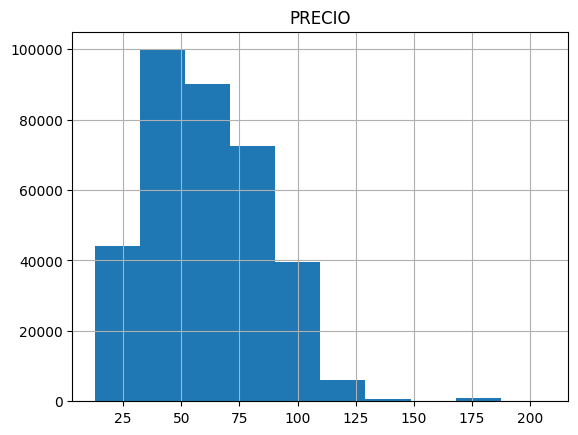

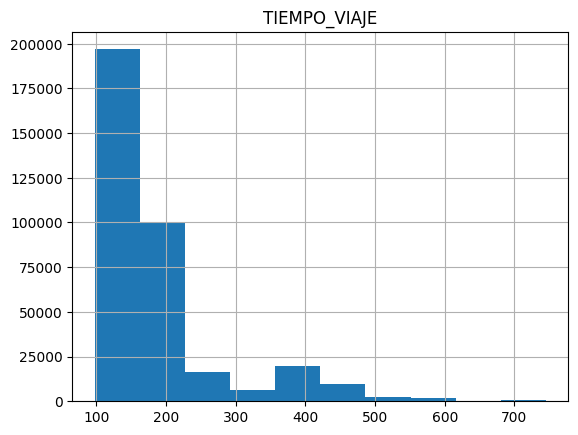

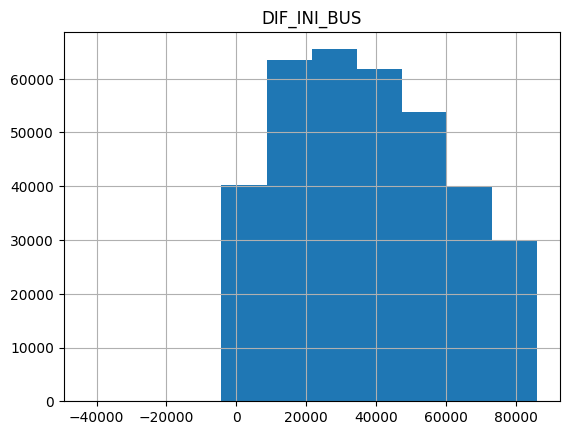

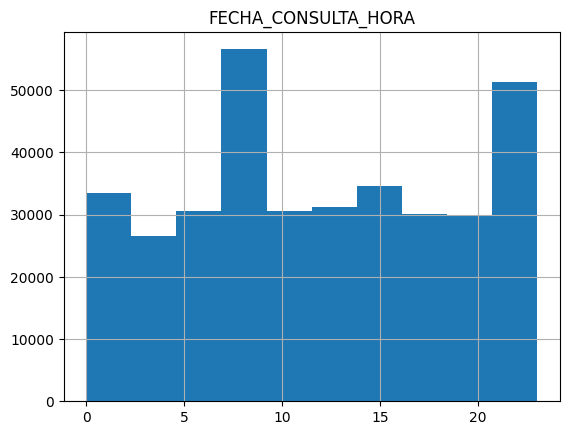

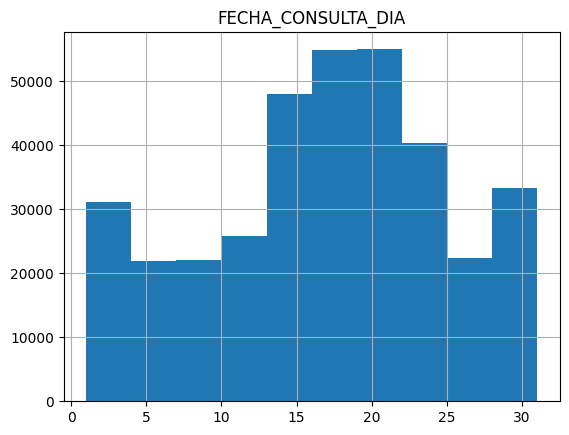

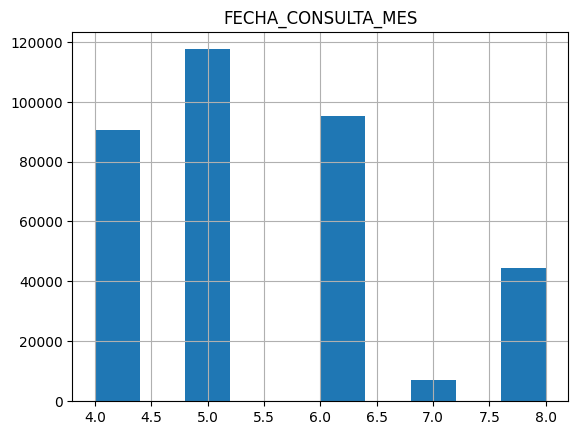

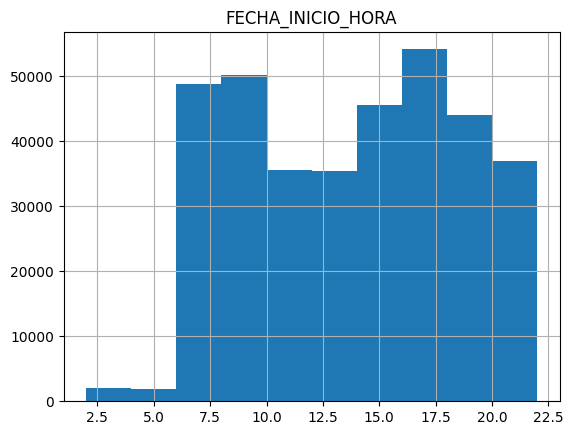

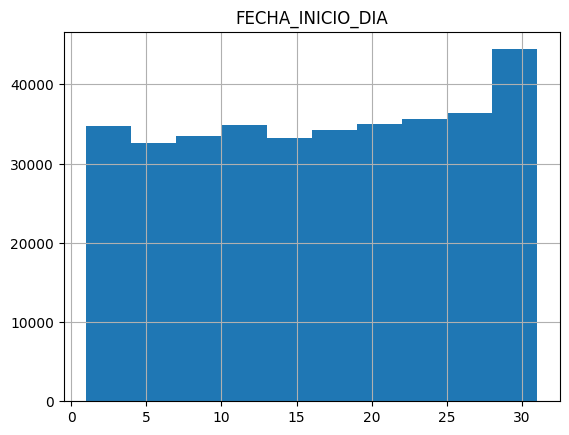

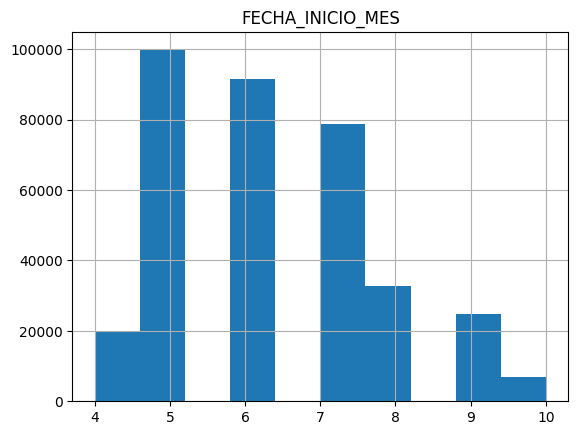

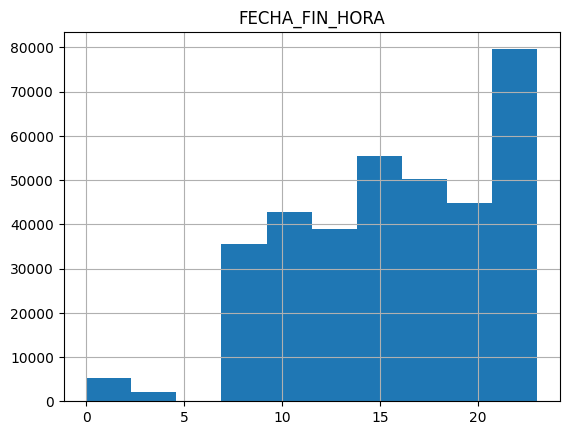

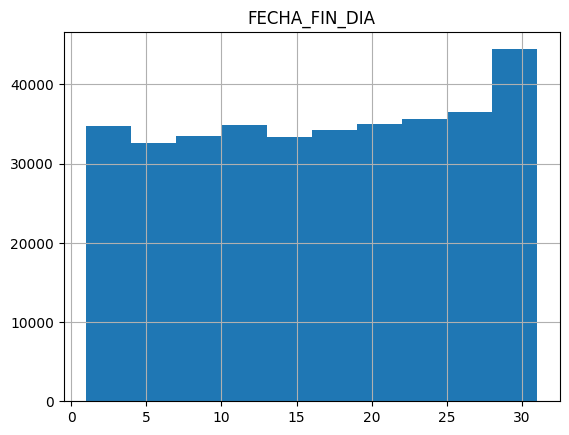

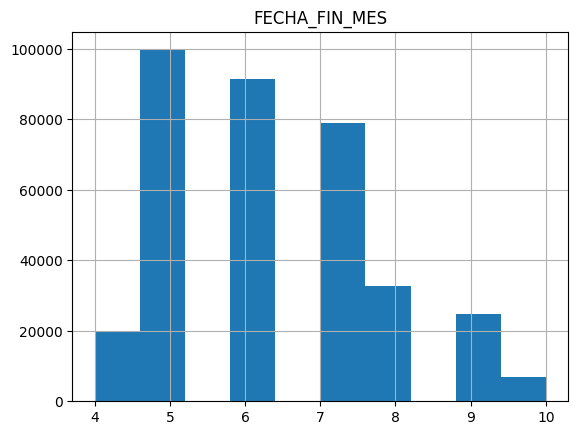

In [64]:
for i in df_renfe_sin_duplicados_nulos_outliers:
  if df_renfe_sin_duplicados_nulos_outliers[i].dtype.kind == "O":
    print(i,'\n', df_renfe_sin_duplicados_nulos_outliers[i].value_counts(), '\n')
  elif (df_renfe_sin_duplicados_nulos_outliers[i].dtype.kind=="f") or (df_renfe_sin_duplicados_nulos_outliers[i].dtype.kind=="i"):
    print(df_renfe_sin_duplicados_nulos_outliers.hist(i))

Mirando las variables categóricas, vemos que hay dos columnas en las que algunos valores aparecen muy pocas veces: TIPO_TARIFA y CLASE. Vamos a eliminarlos.

In [65]:
# La función hace lo siguiente:
#   - como parámetros de entrada tiene un dataset, el nombre de una columna y un valor umbral
#   - crea una lista vacía
#   - crea una tabla con los value counts de la columna del dataset que le pasamos como parámetro de entrada, a la que hace un reset index
#   - se recorre las filas del data set
#   - se pregunta si el nuevo dataset que tiene los conteos de los valores es menor al umbral
#   - en caso de que sea así se agrega en una lista

def obten_lista_eliminar(dataset, columna, umbral):

  lista_borrar = []
  tabla = dataset[columna].value_counts(normalize=True).reset_index()
  print(tabla)

  for i in range(0,len(tabla)):
    if (tabla.iloc[i]["proportion"])*100 < umbral:
      lista_borrar.append(tabla.iloc[i][columna])

  return lista_borrar

# Con esta función podemos eliminar aquellos valores que aparecen muy pocas veces (que serían outliers) de cada variable.

In [66]:
lista_eliminar_tarifa = obten_lista_eliminar(df_renfe_sin_duplicados_nulos_outliers,"TIPO_TARIFA",1)

               TIPO_TARIFA  proportion
0                    Promo    0.719627
1                 Flexible    0.191792
2               Adulto ida    0.064200
3                  Promo +    0.023907
4          COD.PROMOCIONAL    0.000406
5      Individual-Flexible    0.000031
6                     Mesa    0.000020
7  Doble Familiar-Flexible    0.000014
8               Grupos Ida    0.000003


In [67]:
# Esta función tiene como parámetros de entrada un dataset, una columna y una lista.
# Elimina los valores de una columna del dataset que se encuentren en la lista.

def eliminar_lista_df(dataset, columna, lista_eliminar):
  dataset.drop(dataset[dataset[columna].isin(lista_eliminar)].index, inplace=True)

In [68]:
eliminar_lista_df(df_renfe_sin_duplicados_nulos_outliers,"TIPO_TARIFA",lista_eliminar_tarifa)

In [69]:
df_renfe_sin_duplicados_nulos_outliers["TIPO_TARIFA"].value_counts()

TIPO_TARIFA
Promo         255231
Flexible       68023
Adulto ida     22770
Promo +         8479
Name: count, dtype: int64

In [70]:
lista_eliminar_clase = obten_lista_eliminar(df_renfe_sin_duplicados_nulos_outliers, "CLASE", 1)

                      CLASE  proportion
0                   Turista    0.778552
1                Preferente    0.088735
2              Turista Plus    0.065777
3        Turista con enlace    0.060028
4       TuristaSólo plaza H    0.005495
5    PreferenteSólo plaza H    0.000731
6              Cama Turista    0.000677
7  Turista PlusSólo plaza H    0.000006


In [71]:
eliminar_lista_df(df_renfe_sin_duplicados_nulos_outliers,"CLASE",lista_eliminar_clase)

In [72]:
df_renfe_sin_duplicados_nulos_outliers["CLASE"].value_counts()

CLASE
Turista               275999
Preferente             31457
Turista Plus           23318
Turista con enlace     21280
Name: count, dtype: int64

In [73]:
print("Tamaño tabla:",df_renfe_sin_duplicados_nulos_outliers.shape)

Tamaño tabla: (352054, 20)


Ya hemos limpado las variables TIPO_TARIFA y CLASE.

En cuanto a las variables numéricas, vemos que DIF_INI_BUS tiene valores negativos, lo cual no tiene sentido teniendo en cuenta que esta variable es un tiempo. Vamos a eliminar estos valores.

In [74]:
df_renfe_sin_duplicados_nulos_outliers[df_renfe_sin_duplicados_nulos_outliers["DIF_INI_BUS"]<0]

,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO,TIEMPO_VIAJE,DIF_INI_BUS,FECHA_CONSULTA_HORA,FECHA_CONSULTA_NOMBREDIA,FECHA_CONSULTA_DIA,FECHA_CONSULTA_MES,FECHA_INICIO_HORA,FECHA_INICIO_NOMBREDIA,FECHA_INICIO_DIA,FECHA_INICIO_MES,FECHA_FIN_HORA,FECHA_FIN_NOMBREDIA,FECHA_FIN_DIA,FECHA_FIN_MES
882,MADRID,SEVILLA,AVE,Promo,Turista Plus,72.30,160.0,-276.666667,1,Tuesday,28,5,20,Monday,27,5,23,Monday,27,5
1261,MADRID,SEVILLA,MD-LD,Flexible,Turista con enlace,45.80,461.0,-721.800000,1,Tuesday,11,6,13,Monday,10,6,20,Monday,10,6
1347,SEVILLA,MADRID,ALVIA,Flexible,Preferente,87.40,166.0,-932.683333,1,Friday,24,5,9,Thursday,23,5,12,Thursday,23,5
1793,MADRID,VALENCIA,AVE,Promo,Turista,51.15,113.0,-690.116667,1,Thursday,2,5,14,Wednesday,1,5,16,Wednesday,1,5
3220,MADRID,SEVILLA,AVE,Flexible,Turista,76.30,141.0,-1079.166667,1,Wednesday,29,5,7,Tuesday,28,5,9,Tuesday,28,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349800,SEVILLA,MADRID,AVE,Flexible,Turista,76.30,152.0,-508.516667,1,Friday,17,5,16,Thursday,16,5,19,Thursday,16,5
352228,PONFERRADA,MADRID,LD,Flexible,Turista con enlace,57.00,272.0,-503.900000,19,Wednesday,5,6,11,Wednesday,5,6,16,Wednesday,5,6
352391,SEVILLA,MADRID,AVE,Flexible,Turista,76.30,152.0,-401.266667,1,Saturday,27,4,18,Friday,26,4,21,Friday,26,4
352669,SEVILLA,MADRID,INTERCITY,Flexible,Turista,62.20,160.0,-366.083333,1,Thursday,20,6,19,Wednesday,19,6,21,Wednesday,19,6


In [75]:
df_renfe_sin_duplicados_nulos_outliers.drop(df_renfe_sin_duplicados_nulos_outliers[df_renfe_sin_duplicados_nulos_outliers["DIF_INI_BUS"]<0].index,axis=0, inplace=True)

In [76]:
print("Tamaño tabla:",df_renfe_sin_duplicados_nulos_outliers.shape)

Tamaño tabla: (351583, 20)


Ya hemos eliminado los valores negativos de DIF_INI_BUS.

Además, podemos las columnas con el detalle de la hora, el día y el mes de la consulta, puesto que la variable DIF_INI_BUS ya nos da información sobre con qué antelación se compran los billetes.

In [77]:
for i in ("FECHA_CONSULTA_HORA", "FECHA_CONSULTA_NOMBREDIA", "FECHA_CONSULTA_DIA", "FECHA_CONSULTA_MES"):
  del(df_renfe_sin_duplicados_nulos_outliers[i])

In [78]:
for i in ("FECHA_FIN_HORA", "FECHA_FIN_NOMBREDIA", "FECHA_FIN_DIA", "FECHA_FIN_MES"):
  del(df_renfe_sin_duplicados_nulos_outliers[i])

In [79]:
print("Tamaño tabla:",df_renfe_sin_duplicados_nulos_outliers.shape)

Tamaño tabla: (351583, 12)


In [80]:
df_renfe_sin_duplicados_nulos_outliers.head()

,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO,TIEMPO_VIAJE,DIF_INI_BUS,FECHA_INICIO_HORA,FECHA_INICIO_NOMBREDIA,FECHA_INICIO_DIA,FECHA_INICIO_MES
0,SEVILLA,MADRID,ALVIA,Flexible,Turista,67.20,158.0,50092.950000,20,Friday,28,6
1,BARCELONA,MADRID,AVE,Flexible,Turista,107.70,190.0,31494.816667,10,Sunday,14,7
2,SEVILLA,MADRID,AVE,Promo,Turista,47.30,150.0,52275.950000,13,Thursday,23,5
3,VALENCIA,MADRID,REGIONAL,Adulto ida,Turista,28.35,460.0,26968.016667,14,Wednesday,29,5
4,MADRID,BARCELONA,AVE-TGV,Promo,Turista,66.75,179.0,68741.383333,13,Wednesday,26,6


#### GUARDAMOS EL DATASET EN UN FICHERO PICKLE

In [81]:
df_renfe_sin_duplicados_nulos_outliers.to_pickle("df_renfe_clean.pkl") # Guardamos el dataset en un pickle

# Parte 2

## Pregunta 1

In [82]:
df_renfe_clean = pd.read_pickle("df_renfe_clean.pkl")

In [83]:
corr_matrix = df_renfe_clean.select_dtypes(include=["number"]).corr()
corr_matrix

,PRECIO,TIEMPO_VIAJE,DIF_INI_BUS,FECHA_INICIO_HORA,FECHA_INICIO_DIA,FECHA_INICIO_MES
PRECIO,1.000000,-0.237767,-0.235105,0.049394,0.033556,-0.187735
TIEMPO_VIAJE,-0.237767,1.000000,0.017397,-0.184785,-0.006923,0.000201
DIF_INI_BUS,-0.235105,0.017397,1.000000,0.006926,-0.030939,0.453454
FECHA_INICIO_HORA,0.049394,-0.184785,0.006926,1.000000,0.002339,-0.003402
FECHA_INICIO_DIA,0.033556,-0.006923,-0.030939,0.002339,1.000000,-0.294532
FECHA_INICIO_MES,-0.187735,0.000201,0.453454,-0.003402,-0.294532,1.000000


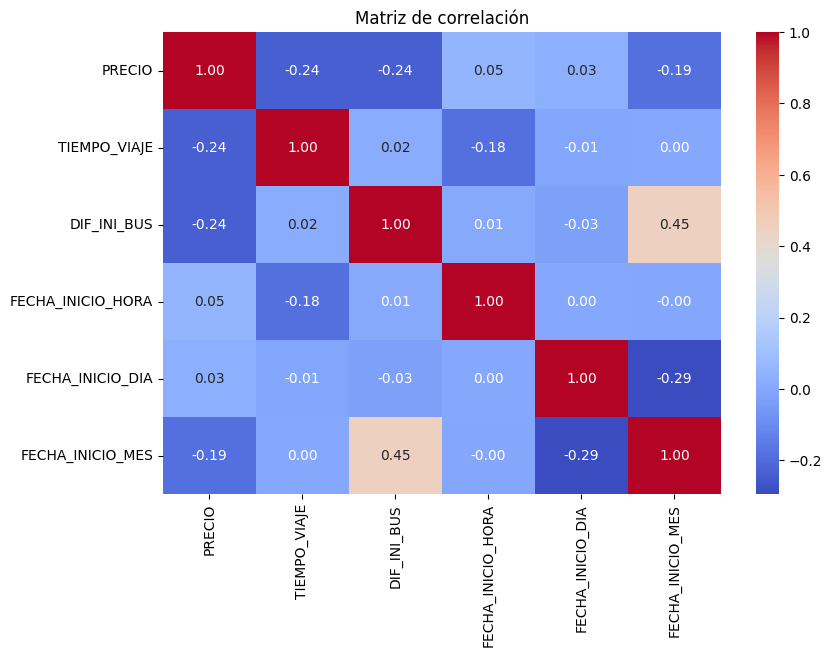

In [ ]:
corr_matrix = df_renfe_clean.select_dtypes(include=["number"]).corr()
plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

## Pregunta 2

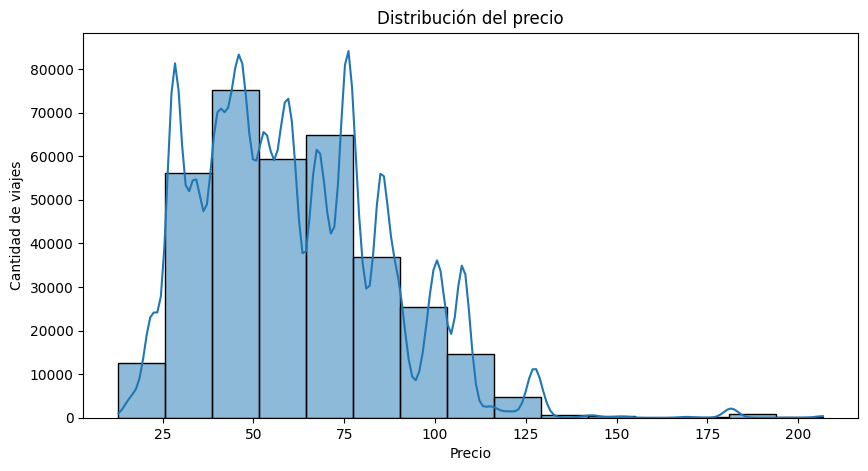

In [85]:
plt.figure(figsize=(10, 5))
sns.histplot(df_renfe_clean['PRECIO'], bins=15, kde=True)
plt.title('Distribución del precio')
plt.xlabel('Precio')
plt.ylabel('Cantidad de viajes')
plt.show()

In [86]:
df_renfe_clean["PRECIO_Log"] = np.log(df_renfe_clean["PRECIO"])


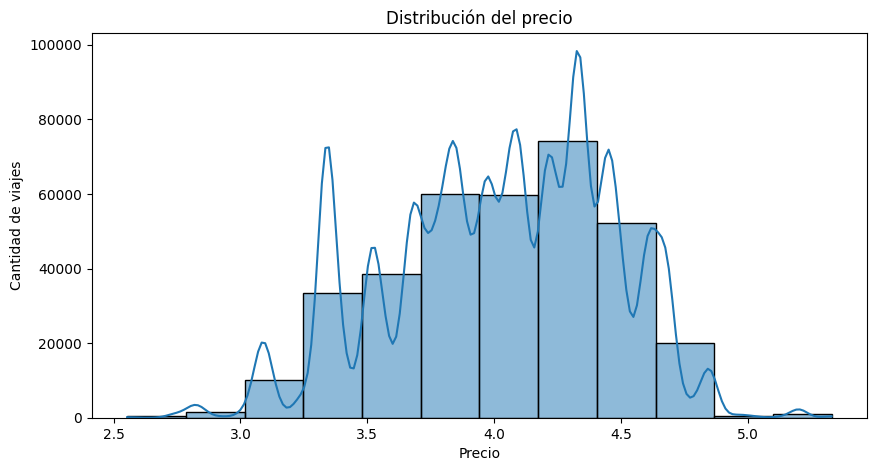

In [87]:
plt.figure(figsize=(10, 5))
sns.histplot(df_renfe_clean['PRECIO_Log'], bins=12, kde=True)
plt.title('Distribución del precio')
plt.xlabel('Precio')
plt.ylabel('Cantidad de viajes')
plt.show()

## Pregunta 3

In [88]:
df_renfe_clean.select_dtypes(include=["object"])

,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,FECHA_INICIO_NOMBREDIA
0,SEVILLA,MADRID,ALVIA,Flexible,Turista,Friday
1,BARCELONA,MADRID,AVE,Flexible,Turista,Sunday
2,SEVILLA,MADRID,AVE,Promo,Turista,Thursday
3,VALENCIA,MADRID,REGIONAL,Adulto ida,Turista,Wednesday
4,MADRID,BARCELONA,AVE-TGV,Promo,Turista,Wednesday
...,...,...,...,...,...,...
354668,MADRID,VALENCIA,AVE,Flexible,Turista,Friday
354669,BARCELONA,MADRID,AVE,Promo,Preferente,Monday
354670,VALENCIA,MADRID,AVE,Promo,Turista,Monday
354671,MADRID,SEVILLA,AVE,Promo,Turista,Sunday


In [89]:
# Ruta del viaje
df_renfe_clean['RUTA'] = df_renfe_clean['CIUDAD_ORIGEN'] + ' - ' + df_renfe_clean['CIUDAD_DESTINO']
df_renfe_clean['RUTA2'] = (df_renfe_clean['RUTA'].str.split(" - ").apply(lambda x: " - ".join(sorted(x))))

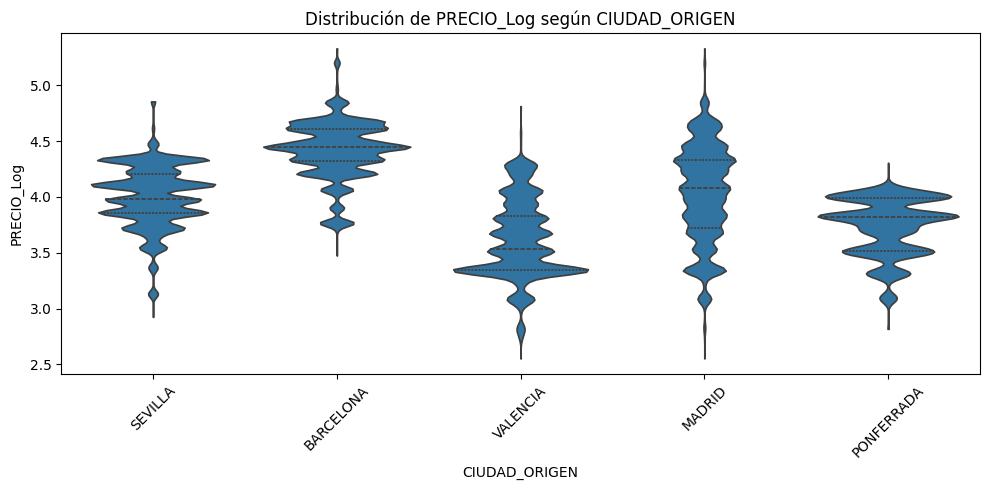

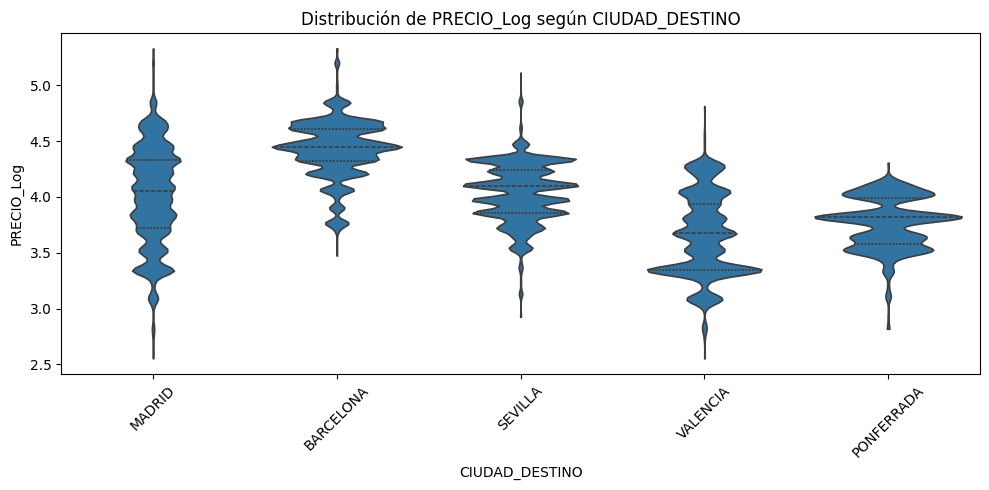

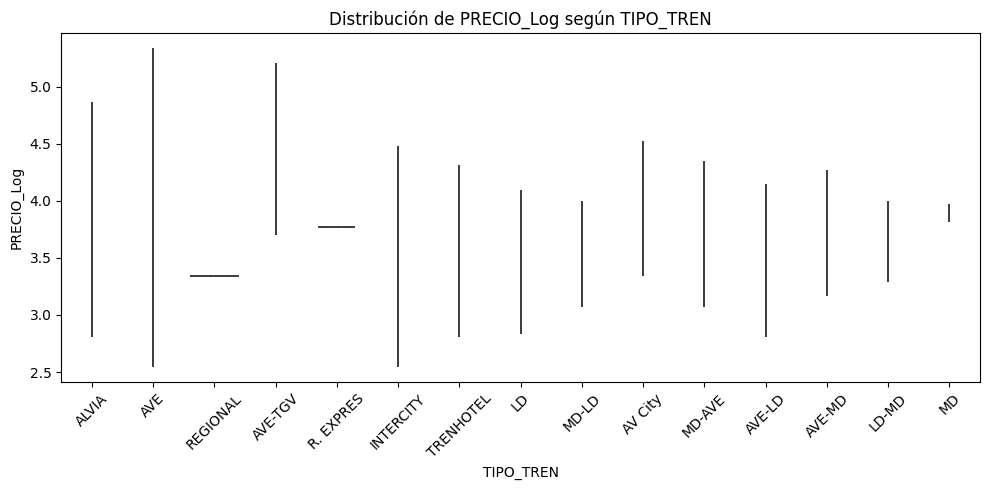

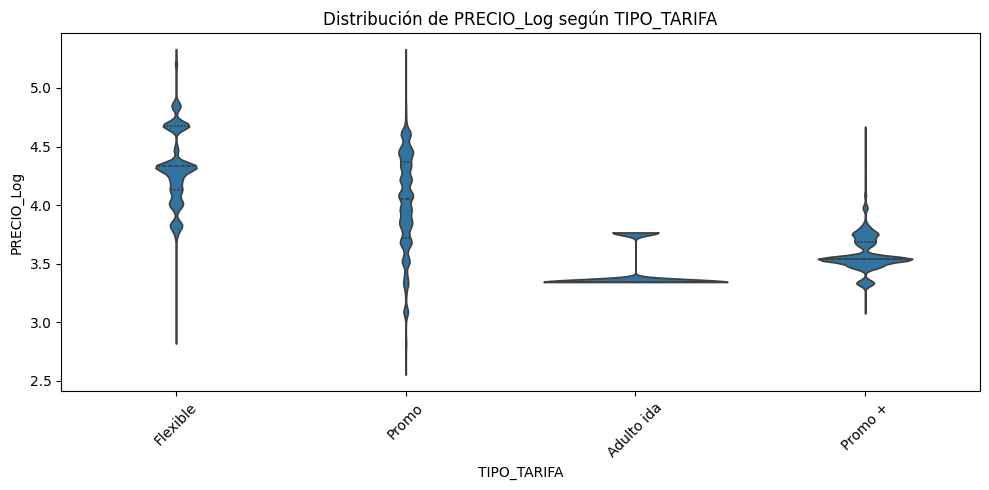

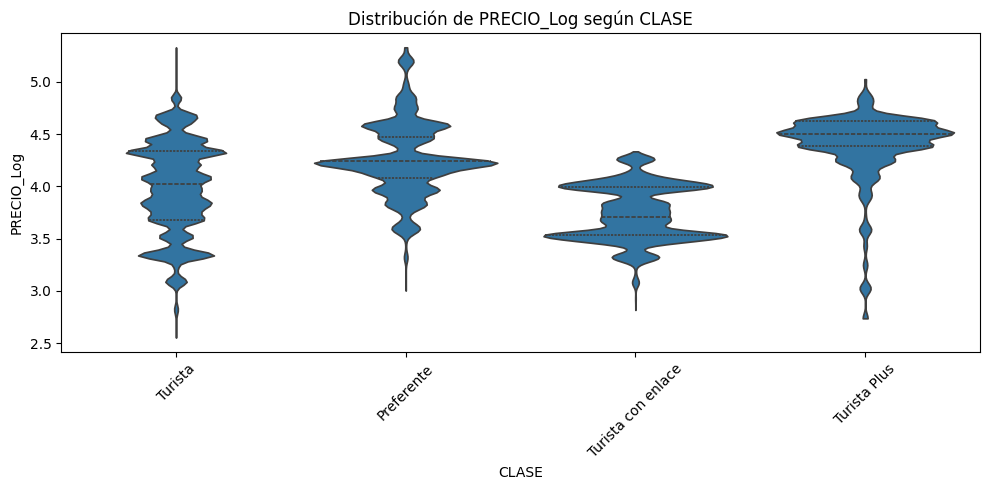

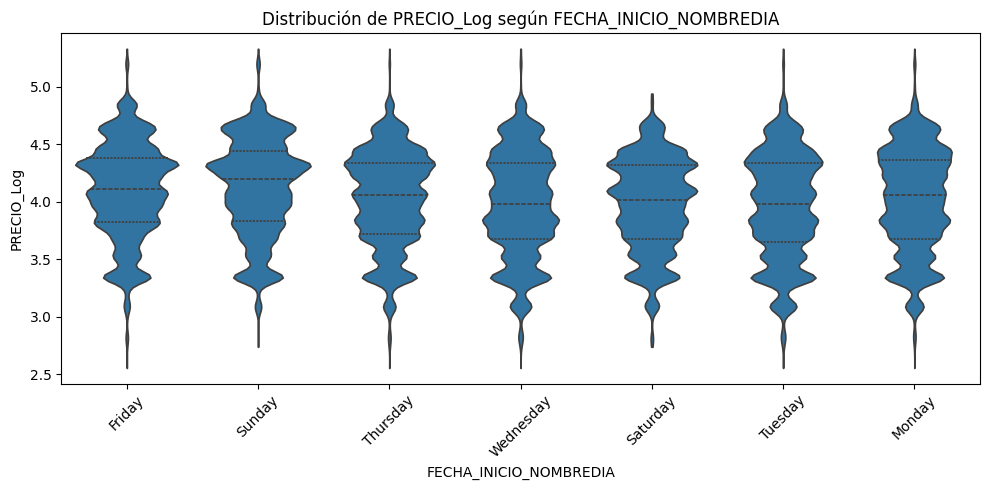

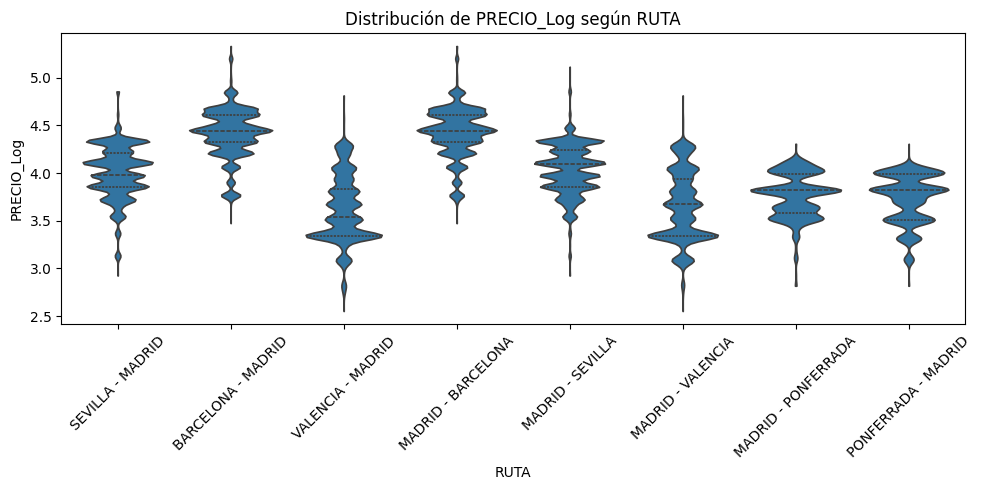

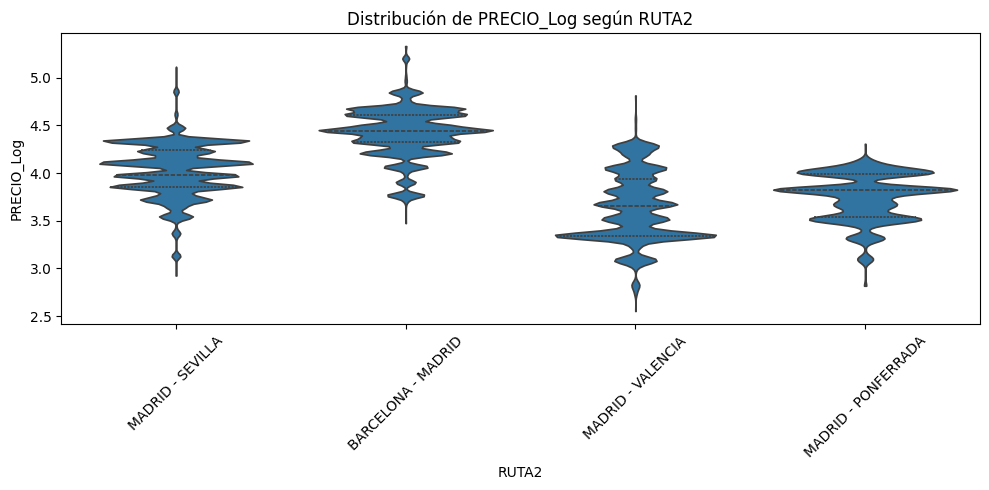

In [90]:
target = "PRECIO_Log"
var_categoricas = df_renfe_clean.select_dtypes(include=["object"]).columns

for col in var_categoricas:
    plt.figure(figsize=(10, 5))
    sns.violinplot(x=col, y=target, data=df_renfe_clean, inner= "quartile", cut = 0)
    plt.title(f'Distribución de {target} según {col}')
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.ylabel(target)
    plt.tight_layout()
    plt.show()

### Relación entre anticipación de compra y precio

In [92]:
df_renfe_clean.select_dtypes(include=["number"]).columns

Index(['PRECIO', 'TIEMPO_VIAJE', 'DIF_INI_BUS', 'FECHA_INICIO_HORA',
       'FECHA_INICIO_DIA', 'FECHA_INICIO_MES', 'PRECIO_Log'],
      dtype='object')

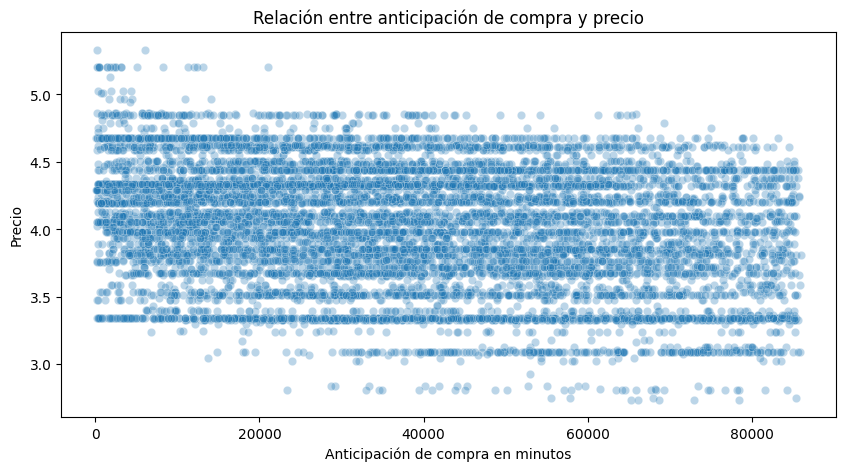

In [98]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df_renfe_clean.sample(min(10000, len(df_renfe_clean)), random_state=42),
    x='DIF_INI_BUS',
    y='PRECIO_Log',
    alpha=0.3
)
plt.title('Relación entre anticipación de compra y precio')
plt.xlabel('Anticipación de compra en minutos')
plt.ylabel('Precio')
plt.show()

In [ ]:
# Eliminamos las columnas innecesarias para el análisis
# CIUDAD_ORIGEN, CIUDAD_DESTINO, PRECIO, 
df_renfe_clean.head(10)

,CIUDAD_ORIGEN,CIUDAD_DESTINO,TIPO_TREN,TIPO_TARIFA,CLASE,PRECIO,TIEMPO_VIAJE,DIF_INI_BUS,FECHA_INICIO_HORA,FECHA_INICIO_NOMBREDIA,FECHA_INICIO_DIA,FECHA_INICIO_MES,PRECIO_Log,RUTA,RUTA2,ANTICIPACION_BUCKET
0,SEVILLA,MADRID,ALVIA,Flexible,Turista,67.20,158.0,50092.950000,20,Friday,28,6,4.207673,SEVILLA - MADRID,MADRID - SEVILLA,30-60 días
1,BARCELONA,MADRID,AVE,Flexible,Turista,107.70,190.0,31494.816667,10,Sunday,14,7,4.679350,BARCELONA - MADRID,BARCELONA - MADRID,14-30 días
2,SEVILLA,MADRID,AVE,Promo,Turista,47.30,150.0,52275.950000,13,Thursday,23,5,3.856510,SEVILLA - MADRID,MADRID - SEVILLA,30-60 días
3,VALENCIA,MADRID,REGIONAL,Adulto ida,Turista,28.35,460.0,26968.016667,14,Wednesday,29,5,3.344627,VALENCIA - MADRID,MADRID - VALENCIA,14-30 días
4,MADRID,BARCELONA,AVE-TGV,Promo,Turista,66.75,179.0,68741.383333,13,Wednesday,26,6,4.200954,MADRID - BARCELONA,BARCELONA - MADRID,30-60 días
5,MADRID,SEVILLA,AVE,Promo,Preferente,69.35,158.0,65396.733333,9,Saturday,5,10,4.239166,MADRID - SEVILLA,MADRID - SEVILLA,30-60 días
6,MADRID,VALENCIA,AVE,Promo,Turista,51.15,100.0,1692.616667,12,Tuesday,16,4,3.934762,MADRID - VALENCIA,MADRID - VALENCIA,1-3 días
7,MADRID,BARCELONA,AVE,Promo,Turista,66.75,190.0,2743.283333,17,Saturday,1,6,4.200954,MADRID - BARCELONA,BARCELONA - MADRID,1-3 días
8,MADRID,BARCELONA,R. EXPRES,Adulto ida,Turista,43.25,562.0,44127.266667,7,Wednesday,12,6,3.766997,MADRID - BARCELONA,BARCELONA - MADRID,30-60 días
9,MADRID,VALENCIA,REGIONAL,Adulto ida,Turista,28.35,407.0,60230.583333,6,Monday,27,5,3.344627,MADRID - VALENCIA,MADRID - VALENCIA,30-60 días


In [99]:
# Agrupar anticipación de compra en intervalos para facilitar el análisis
df_renfe_clean['ANTICIPACION_BUCKET'] = pd.cut(
    df_renfe_clean['DIF_INI_BUS']/1440,  # Convertir minutos a días
    bins=[0, 1, 3, 7, 14, 30, 60, 90, np.inf],
    labels=['0-1 días', '1-3 días', '3-7 días', '7-14 días', '14-30 días', '30-60 días', '60-90 días', '+90 días'],
    include_lowest=True
)

price_by_anticipation = (
    df_renfe_clean
    .groupby('ANTICIPACION_BUCKET', observed=False)
    .agg(
        cantidad=('PRECIO_Log', 'count'),
        precio_medio=('PRECIO_Log', 'mean'),
        precio_mediano=('PRECIO_Log', 'median')
    )
)

price_by_anticipation

,cantidad,precio_medio,precio_mediano
ANTICIPACION_BUCKET,,,
0-1 días,5493,4.296313,4.334673
1-3 días,12701,4.244674,4.291828
3-7 días,26621,4.174651,4.200954
7-14 días,49305,4.109270,4.130355
14-30 días,114897,4.037579,4.063026
30-60 días,142566,3.925919,3.959860
60-90 días,0,NaN,NaN
+90 días,0,NaN,NaN


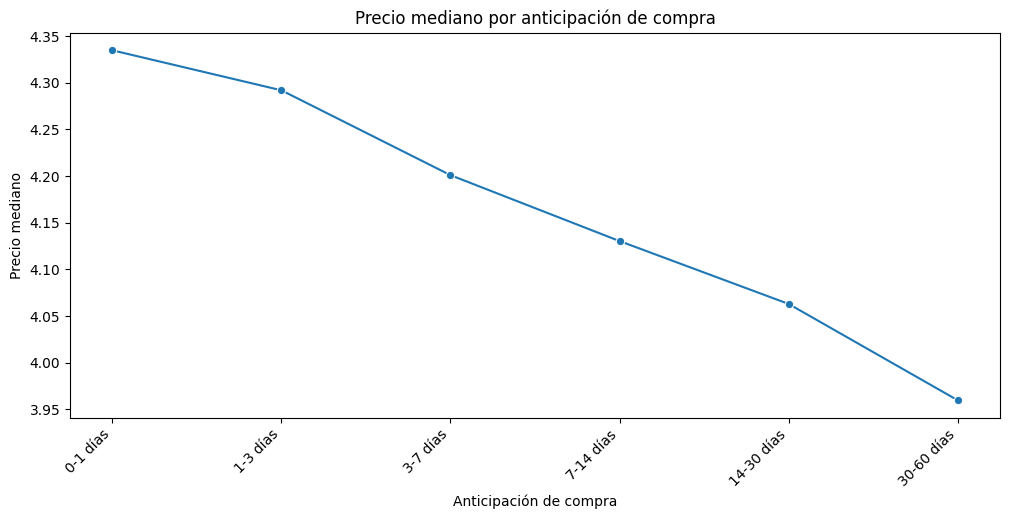

In [100]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=price_by_anticipation.reset_index(), x='ANTICIPACION_BUCKET', y='precio_mediano', marker='o')
plt.title('Precio mediano por anticipación de compra')
plt.xlabel('Anticipación de compra')
plt.ylabel('Precio mediano')
plt.xticks(rotation=45, ha='right')
plt.show()

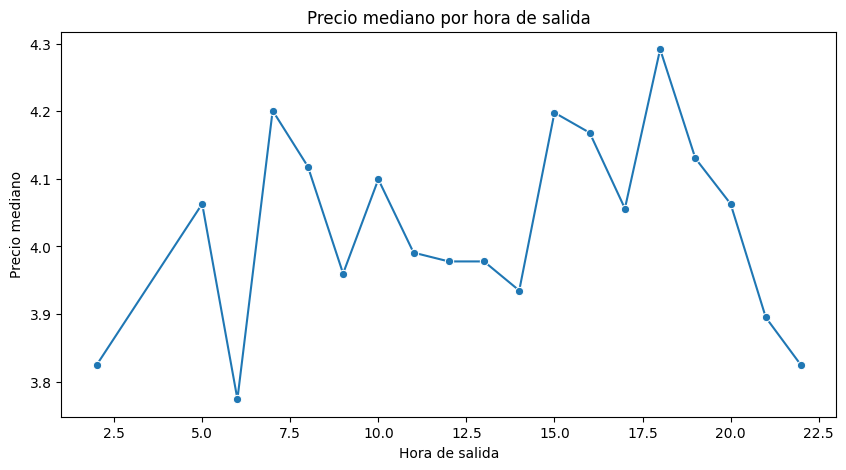

In [102]:
price_by_hour = (
    df_renfe_clean
    .groupby('FECHA_INICIO_HORA')
    .agg(
        cantidad=('PRECIO_Log', 'count'),
        precio_mediano=('PRECIO_Log', 'median')
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=price_by_hour, x='FECHA_INICIO_HORA', y='precio_mediano', marker='o')
plt.title('Precio mediano por hora de salida')
plt.xlabel('Hora de salida')
plt.ylabel('Precio mediano')
plt.show()


## PREGUNTA 5

In [110]:
df_renfe_clean['CLASE'].value_counts()

CLASE
Turista               275678
Preferente             31359
Turista Plus           23288
Turista con enlace     21258
Name: count, dtype: int64

In [120]:
# ANALIZAMOS LAS VARIABLES, ELIMINAMOS REDUNDANTES Y APLICAMOS ONE HOT ENCODING
# Eliminamos CIUDAD_ORIGEN, CIUDAD_DESTINO, PRECIO, RUTA
# Convertimos FECHA_INICIO_HORA, FECHA_INICIO_DIA, FECHA_INICIO_MEs a variable categórica porque es la hora del día, no un valor numérico que tenga sentido interpretar como tal. Además, al convertirla a categórica, podemos aplicar One Hot Encoding para capturar la información de la hora sin asumir una relación lineal entre las horas.
# Convertimos ANTICIPACION_BUCKET a variable categórica porque es un bucket de días, no un valor numérico que tenga sentido interpretar como tal. Además, al convertirla a categórica, podemos aplicar One Hot Encoding para capturar la información de la anticipación sin asumir una relación lineal entre los buckets.
df_renfe_categoricas = df_renfe_clean.copy()
df_renfe_categoricas = df_renfe_categoricas.drop(columns=['CIUDAD_ORIGEN', 'CIUDAD_DESTINO', 'PRECIO', 'RUTA'])
df_renfe_categoricas['FECHA_INICIO_HORA'] = df_renfe_categoricas['FECHA_INICIO_HORA'].astype('object')
df_renfe_categoricas['FECHA_INICIO_DIA'] = df_renfe_categoricas['FECHA_INICIO_DIA'].astype('object')
df_renfe_categoricas['FECHA_INICIO_MES'] = df_renfe_categoricas['FECHA_INICIO_MES'].astype('object')
df_renfe_categoricas['ANTICIPACION_BUCKET'] = df_renfe_categoricas['ANTICIPACION_BUCKET'].astype('object')
df_renfe_categoricas.head()

,TIPO_TREN,TIPO_TARIFA,CLASE,TIEMPO_VIAJE,DIF_INI_BUS,FECHA_INICIO_HORA,FECHA_INICIO_NOMBREDIA,FECHA_INICIO_DIA,FECHA_INICIO_MES,PRECIO_Log,RUTA2,ANTICIPACION_BUCKET
0,ALVIA,Flexible,Turista,158.0,50092.950000,20,Friday,28,6,4.207673,MADRID - SEVILLA,30-60 días
1,AVE,Flexible,Turista,190.0,31494.816667,10,Sunday,14,7,4.679350,BARCELONA - MADRID,14-30 días
2,AVE,Promo,Turista,150.0,52275.950000,13,Thursday,23,5,3.856510,MADRID - SEVILLA,30-60 días
3,REGIONAL,Adulto ida,Turista,460.0,26968.016667,14,Wednesday,29,5,3.344627,MADRID - VALENCIA,14-30 días
4,AVE-TGV,Promo,Turista,179.0,68741.383333,13,Wednesday,26,6,4.200954,BARCELONA - MADRID,30-60 días


In [129]:
# Convertimos las variables categóricas a numéricas utilizando One Hot Encoding en valor numerico, eliminando la primera categoría para evitar la multicolinealidad.
df_renfe_categoricas= pd.get_dummies(df_renfe_categoricas,  drop_first=True).astype('int64')
df_renfe_categoricas.head()

,TIEMPO_VIAJE,DIF_INI_BUS,PRECIO_Log,TIPO_TREN_AV City,TIPO_TREN_AVE,TIPO_TREN_AVE-LD,TIPO_TREN_AVE-MD,TIPO_TREN_AVE-TGV,TIPO_TREN_INTERCITY,TIPO_TREN_LD,...,FECHA_INICIO_MES_9,FECHA_INICIO_MES_10,RUTA2_MADRID - PONFERRADA,RUTA2_MADRID - SEVILLA,RUTA2_MADRID - VALENCIA,ANTICIPACION_BUCKET_1-3 días,ANTICIPACION_BUCKET_14-30 días,ANTICIPACION_BUCKET_3-7 días,ANTICIPACION_BUCKET_30-60 días,ANTICIPACION_BUCKET_7-14 días
0,0,0,4,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1,0,0,4,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,0,0,3,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
3,0,0,3,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
4,0,0,4,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0


In [130]:
# Escalamos las variables numéricas utilizando MinMaxScaler, sin incluir la variable objetivo (PRECIO_Log)
scaler = MinMaxScaler()
numerical_cols = ['TIEMPO_VIAJE', 'DIF_INI_BUS']
df_renfe_categoricas[numerical_cols] = scaler.fit_transform(df_renfe_categoricas[numerical_cols])
df_renfe_categoricas.head()

,TIEMPO_VIAJE,DIF_INI_BUS,PRECIO_Log,TIPO_TREN_AV City,TIPO_TREN_AVE,TIPO_TREN_AVE-LD,TIPO_TREN_AVE-MD,TIPO_TREN_AVE-TGV,TIPO_TREN_INTERCITY,TIPO_TREN_LD,...,FECHA_INICIO_MES_9,FECHA_INICIO_MES_10,RUTA2_MADRID - PONFERRADA,RUTA2_MADRID - SEVILLA,RUTA2_MADRID - VALENCIA,ANTICIPACION_BUCKET_1-3 días,ANTICIPACION_BUCKET_14-30 días,ANTICIPACION_BUCKET_3-7 días,ANTICIPACION_BUCKET_30-60 días,ANTICIPACION_BUCKET_7-14 días
0,0.0,0.0,4,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1,0.0,0.0,4,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,0.0,0.0,3,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
3,0.0,0.0,3,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
4,0.0,0.0,4,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
# convertir variables booleanas a numericas 0 y 1
df_re

## Intentamos aplicar algun modelos

In [ ]:
# Generamos la matriz de correlacion y mostramos solo las correlaciones mayores a 0.8 en valor absoluto para identificar posibles multicolinealidades entre las variables.
corr_matrix = df_renfe_categoricas.select_dtypes(include=["number"]).corr()
# Mostramos como lista las correlaciones mayores a 0.8 en valor absoluto para identificar posibles multicolinealidades entre las variables.
corr_matrix[corr_matrix.abs() > 0.8]

,TIEMPO_VIAJE,DIF_INI_BUS,PRECIO_Log,TIPO_TREN_AV City,TIPO_TREN_AVE,TIPO_TREN_AVE-LD,TIPO_TREN_AVE-MD,TIPO_TREN_AVE-TGV,TIPO_TREN_INTERCITY,TIPO_TREN_LD,...,FECHA_INICIO_MES_9,FECHA_INICIO_MES_10,RUTA2_MADRID - PONFERRADA,RUTA2_MADRID - SEVILLA,RUTA2_MADRID - VALENCIA,ANTICIPACION_BUCKET_1-3 días,ANTICIPACION_BUCKET_14-30 días,ANTICIPACION_BUCKET_3-7 días,ANTICIPACION_BUCKET_30-60 días,ANTICIPACION_BUCKET_7-14 días
TIEMPO_VIAJE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DIF_INI_BUS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PRECIO_Log,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TIPO_TREN_AV City,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TIPO_TREN_AVE,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ANTICIPACION_BUCKET_1-3 días,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
ANTICIPACION_BUCKET_14-30 días,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
ANTICIPACION_BUCKET_3-7 días,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
ANTICIPACION_BUCKET_30-60 días,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN


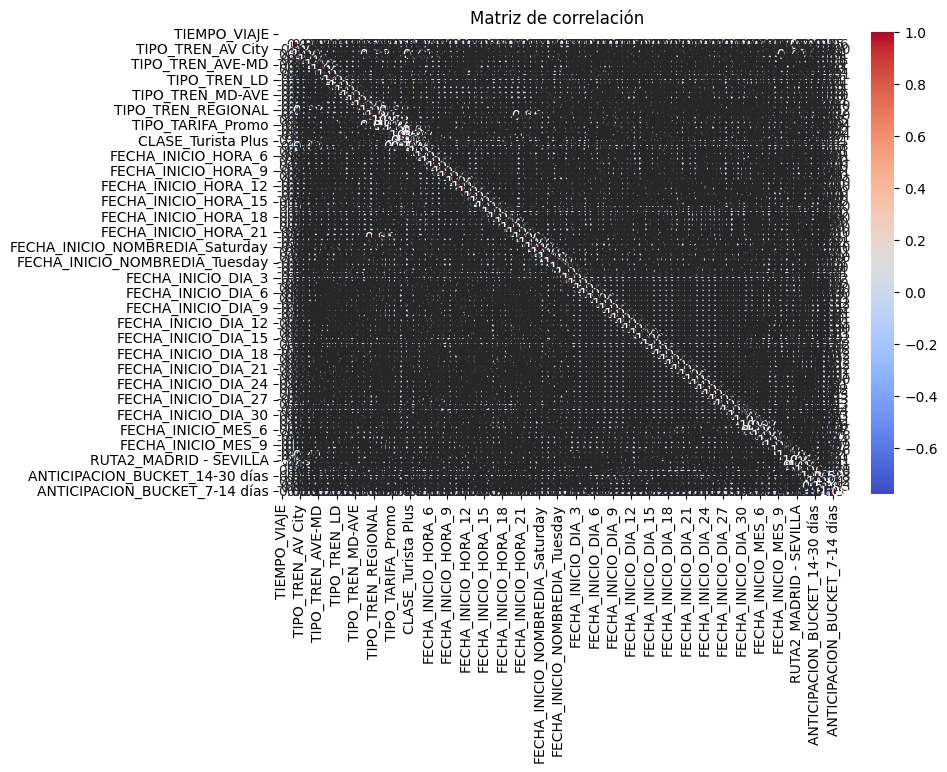

In [ ]:

plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

In [124]:
import sklearn.linear_model
modelo = sklearn.linear_model.LinearRegression()

In [126]:
# Aplicamos un modelo de regresión lineal para predecir el precio del viaje (PRECIO_Log) a partir de las variables categóricas y numéricas procesadas. Para ello, separamos la variable objetivo (PRECIO_Log) de las variables predictoras, dividimos el dataset en conjuntos de entrenamiento y prueba, entrenamos el modelo y evaluamos su rendimiento utilizando métricas como el R² y el error cuadrático medio (MSE). Además, analizamos los coeficientes del modelo para entender la importancia de cada variable en la predicción del precio.    

X = df_renfe_categoricas.drop(columns=['PRECIO_Log'])
y = df_renfe_categoricas['PRECIO_Log']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'R²: {r2:.4f}')
print(f'MSE: {mse:.4f}')    

R²: 0.8263
MSE: 0.0329


/Users/juanceruso/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/juanceruso/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/juanceruso/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
